## Downloading the file

# compression

In [29]:
%%time
from compression import zstd
import chess.pgn

file_path = "/home/nabin2004/Desktop/projects/lichess/data/raw/lichess_db_standard_rated_2013-01.pgn.zst"

with zstd.open(file_path, "rt", encoding="utf-8") as f:
    first_game = chess.pgn.read_game(f)
    print(first_game)

[Event "Rated Classical game"]
[Site "https://lichess.org/j1dkb5dw"]
[Date "????.??.??"]
[Round "?"]
[White "BFG9k"]
[Black "mamalak"]
[Result "1-0"]
[UTCDate "2012.12.31"]
[UTCTime "23:01:03"]
[WhiteElo "1639"]
[BlackElo "1403"]
[WhiteRatingDiff "+5"]
[BlackRatingDiff "-8"]
[ECO "C00"]
[Opening "French Defense: Normal Variation"]
[TimeControl "600+8"]
[Termination "Normal"]

1. e4 e6 2. d4 b6 3. a3 Bb7 4. Nc3 Nh6 5. Bxh6 gxh6 6. Be2 Qg5 7. Bg4 h5 8. Nf3 Qg6 9. Nh4 Qg5 10. Bxh5 Qxh4 11. Qf3 Kd8 12. Qxf7 Nc6 13. Qe8# 1-0
CPU times: user 1.27 ms, sys: 997 μs, total: 2.27 ms
Wall time: 1.88 ms


# Divide the sections    

1. Metadata section
    - event
    - site
    - date
    - round
    - player (white, black)
    - result (1-0) {1,0,1/2}
    - utc_date (server time)
    - utc_time (server time)
    - white_elo
    - black_elo
    - white_rating_diff
    - black_rating_diff
    - opening_info:
        - eco: `C00`: classification code for opening
        - opening: French Defense - Normal Variation
    - time_control: 600+8 (in seconds with inremental time)
    - termination

2. Moves section
This is Standard Algebraic Notation (SAN).
    - 1. e4 e6 
    - 2. d4 b6
    - Qe8# ::: `#` = checkmate

In [30]:
first_game.headers

Headers(Event='Rated Classical game', Site='https://lichess.org/j1dkb5dw', Date='????.??.??', Round='?', White='BFG9k', Black='mamalak', Result='1-0', UTCDate='2012.12.31', UTCTime='23:01:03', WhiteElo='1639', BlackElo='1403', WhiteRatingDiff='+5', BlackRatingDiff='-8', ECO='C00', Opening='French Defense: Normal Variation', TimeControl='600+8', Termination='Normal')

In [33]:
first_game.mainline_moves()

<Mainline at 0x7b7d6c852120 (1. e4 e6 2. d4 b6 3. a3 Bb7 4. Nc3 Nh6 5. Bxh6 gxh6 6. Be2 Qg5 7. Bg4 h5 8. Nf3 Qg6 9. Nh4 Qg5 10. Bxh5 Qxh4 11. Qf3 Kd8 12. Qxf7 Nc6 13. Qe8#)>

In [34]:
for move in first_game.mainline_moves():
    print(move)

e2e4
e7e6
d2d4
b7b6
a2a3
c8b7
b1c3
g8h6
c1h6
g7h6
f1e2
d8g5
e2g4
h6h5
g1f3
g5g6
f3h4
g6g5
g4h5
g5h4
d1f3
e8d8
f3f7
b8c6
f7e8


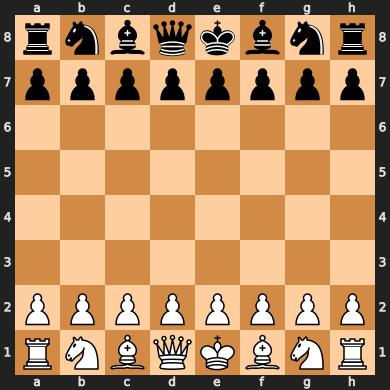

In [41]:
first_game.board()

In [40]:
first_game.next

<bound method GameNode.next of <Game at 0x7b7d4f010440 ('BFG9k' vs. 'mamalak', '????.??.??' at 'https://lichess.org/j1dkb5dw')>>

In [32]:
dir(first_game)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 'accept',
 'accept_subgame',
 'add_line',
 'add_main_variation',
 'add_variation',
 'arrows',
 'board',
 'builder',
 'clock',
 'comment',
 'demote',
 'emt',
 'end',
 'errors',
 'eval',
 'eval_depth',
 'from_board',
 'game',
 'has_variation',
 'headers',
 'is_end',
 'is_main_variation',
 'is_mainline',
 'mainline',
 'mainline_moves',
 'move',
 'nags',
 'next',
 'parent',
 'ply',
 'promote',
 'promote_to_main',
 'remove_variation',
 'root',
 'set_arrows',
 's

In [42]:
first_game.is_end()

False

In [43]:
first_game.mainline()

<Mainline at 0x7b7d5454b890 (1. e4 e6 2. d4 b6 3. a3 Bb7 4. Nc3 Nh6 5. Bxh6 gxh6 6. Be2 Qg5 7. Bg4 h5 8. Nf3 Qg6 9. Nh4 Qg5 10. Bxh5 Qxh4 11. Qf3 Kd8 12. Qxf7 Nc6 13. Qe8#)>

# TODOS:
- [x] pgn.zst ->  PGN -> Parquet pipeline: Build a clean dataset pipeline: Output: `lichess_2013_01.parquet`
- [x] Validate dataset: count matches, no missing elo, result values clean, no broken games
- [ ] Analyze the game more.

# pgn.zst to parquet pipeline

In [52]:
from compression import zstd
import chess.pgn
import pyarrow as pa
import pyarrow.parquet as pq

INPUT = "/home/nabin2004/Desktop/projects/lichess/data/raw/lichess_db_standard_rated_2013-01.pgn.zst"
OUTPUT = "/home/nabin2004/Desktop/projects/lichess/data/processed/2013-01.parquet"

BATCH_SIZE = 5000

def safe_int(x):
    if x is None:
        return None
    if x == "?" or x == "":
        return None
    try:
        return int(x)
    except:
        return None


def parse_game(game):
    headers = game.headers

    moves = []
    node = game

    while not node.is_end():
        node = node.variation(0)
        if node.move:
            moves.append(node.move.uci())

    return {
        "event": headers.get("Event"),
        "site": headers.get("Site"),
        "date": headers.get("Date"),
        "round": headers.get("Round"),

        "white": headers.get("White"),
        "black": headers.get("Black"),

        "result": headers.get("Result"),

        "utc_date": headers.get("UTCDate"),
        "utc_time": headers.get("UTCTime"),
        "white_elo": safe_int(headers.get("WhiteElo")),
        "black_elo": safe_int(headers.get("BlackElo")),
        "white_rating_diff": safe_int(headers.get("WhiteRatingDiff")),
        "black_rating_diff": safe_int(headers.get("BlackRatingDiff")),
        "eco": headers.get("ECO"),
        "opening": headers.get("Opening"),

        "time_control": headers.get("TimeControl"),
        "termination": headers.get("Termination"),
        "moves": moves,
    }


def write_parquet_stream(input_path, output_path):
    batch = []
    writer = None
    total = 0

    with zstd.open(input_path, "rt", encoding="utf-8") as f:
        while True:
            game = chess.pgn.read_game(f)
            if game is None:
                break

            batch.append(parse_game(game))
            total += 1

            # write batch
            if len(batch) >= BATCH_SIZE:
                table = pa.Table.from_pylist(batch)

                if writer is None:
                    writer = pq.ParquetWriter(output_path, table.schema)

                writer.write_table(table)
                batch.clear()

        # flush remaining
        if batch:
            table = pa.Table.from_pylist(batch)

            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)

            writer.write_table(table)

    if writer:
        writer.close()

    print(f"Done. Games processed: {total:,}")
    print(f"Saved to: {output_path}")

write_parquet_stream(INPUT, OUTPUT)

Done. Games processed: 121,332
Saved to: /home/nabin2004/Desktop/projects/lichess/data/processed/2013-01.parquet


In [48]:
game.headers.get("WhiteElo", 0)

'1352'

# Validation
- [x] game count matches official Lichess number 
- [x] no missing / broken fields
- [x] Elo values are clean
- [x] results are valid
- [x] no corrupted games during parsing

In [ ]:
expected_count = 5000
count = 0

def expected_count_reached():
    global count
    count += 1
    if count >= expected_count:
        print(f"Expected count of {expected_count} reached.")
        return True
    return False

In [ ]:
def validate_elo(elo):
    pass 

In [ ]:
def validate_result(result):
    pass

In [ ]:
def detect_broken_games(game):
    pass

In [ ]:
def full_validation(game):
    pass

# Data Preprocessing

# Feature Engineering

## Pre‑game features
1. Elo difference: (white_elo - black_elo)
2. Average Elo: (white_elo + black_elo) / 2
3. Time control base and increment: (parse "600+8" → 600, 8)
4. Presence of title: 1 if player has a title (GM, IM, FM, etc.), else 0
5. Day of week / hour (from UTCDate, UTCTime) – subtle but can capture fatigue patterns

## In‑game dynamics
```
Important: To avoid target leakage, these features must be computable without knowing the final result and ideally at a fixed point (e.g., after 10 moves) or as aggregates of the whole game (which is safe only if we are not using them to predict a moving target before the game ends but for a post‑game prediction it’s fine).
```
- Game length (number of plies) – can be used as a feature for outcome, but be careful if you also use it as a regression target.
- Termination type (Normal, Time forfeit, Abandoned, etc.) – one‑hot encode
- Number of checks given by each side
- Number of captures by each side
- Castling flags (0/1 for white kingside, white queenside, etc.)
- Early queen development (queen moved before move 10)
- Material balance after 10 moves (sum of piece values from White’s perspective)
- Pawn structure metrics (doubled pawns, isolated pawns) – computationally heavier, optional

### If we have engine evaluations, you can compute:
- ACPL (Average Centipawn Loss) for White / Black – great regression target or feature
- Blunder count (>200 cp loss)
- Mistake count (100‑200 cp)
- Inaccuracy count (50‑100 cp)
- Evaluation after 10 moves (centipawns)
- Maximum evaluation swing during the game


### If we have clock times (real or simulated):
- Average time per move for each player
- Time pressure flag (clock dropped below 30s)
- Time remaining at move 20
- Variance of move times (nervousness?)

# Temporal Train Test Split

In [57]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

X = np.array([[1, 2], [3, 4], [1, 2], [3, 4], [1, 2], [3, 4]])
y = np.array([1, 2, 3, 4, 5, 6])

tscv = TimeSeriesSplit()

print(tscv)

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)
Fold 0:
  Train: index=[0]
  Test:  index=[1]
Fold 1:
  Train: index=[0 1]
  Test:  index=[2]
Fold 2:
  Train: index=[0 1 2]
  Test:  index=[3]
Fold 3:
  Train: index=[0 1 2 3]
  Test:  index=[4]
Fold 4:
  Train: index=[0 1 2 3 4]
  Test:  index=[5]
